# Funciones para preparar los datos del proyecto

Notebook con una funcion por etapa para preparar los datos de `dataproject`.

In [4]:
import pandas as pd
from pathlib import Path
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

## Funciones paso a paso
### Importación de datos

Realizamos una función load_data en el que indicamos el path y el nrow = número de filas que queremos, si queremos hacer pruebas rápidas con un número menor de filas.

In [5]:
def load_data(path: str, nrows: int | None = None) -> pd.DataFrame:
    """
    Carga un CSV en un DataFrame de pandas.

    Parámetros:
    - path: ruta al archivo CSV.
    - nrows: si no es None, limita el número de filas leídas (útil para pruebas).

    Devuelve:
    - df: DataFrame con los datos cargados.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"El archivo {path} no existe.")
    
    df = pd.read_csv(path, nrows=nrows)
    return df


Aplicamos la función a nuestros datos

In [8]:
train_df = load_data("../data/raw/train.csv")
test_df = load_data("../data/raw/test.csv")

### Función para inspección rápida del DataFrame
Qué hace:

- Imprime número de filas y columnas.

- Lista los tipos de cada columna.

- Muestra las primeras 5 filas para tener una idea del contenido.

In [9]:
def basic_overview(df: pd.DataFrame, name: str = "DataFrame") -> None:
    """
    Muestra información básica del DataFrame:
    - nombre, shape
    - tipos de datos
    - primeras filas

    Solo imprime información, no devuelve nada.
    """
    print(f"=== Resumen de {name} ===")
    print(f"Shape: {df.shape[0]} filas, {df.shape[1]} columnas\n")
    
    print("Tipos de datos:")
    print(df.dtypes)
    print("\nPrimeras 5 filas:")
    display(df.head())


In [10]:
basic_overview(train_df, name="train")
basic_overview(test_df, name="test")

=== Resumen de train ===
Shape: 125000 filas, 20 columnas

Tipos de datos:
customer_id                     int64
age                             int64
location                          str
subscription_type                 str
payment_plan                      str
num_subscription_pauses         int64
payment_method                    str
customer_service_inquiries        str
signup_date                     int64
weekly_hours                  float64
average_session_length        float64
song_skip_rate                float64
weekly_songs_played             int64
weekly_unique_songs             int64
num_favorite_artists            int64
num_platform_friends            int64
num_playlists_created           int64
num_shared_playlists            int64
notifications_clicked           int64
churned                         int64
dtype: object

Primeras 5 filas:


,customer_id,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,signup_date,weekly_hours,average_session_length,song_skip_rate,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned
0,1,32,Montana,Free,Yearly,2,Paypal,Medium,-1606,22.391362,105.394516,0.176873,169,109,18,32,52,35,46,0
1,2,64,New Jersey,Free,Monthly,3,Paypal,Low,-2897,29.294210,52.501115,0.981811,55,163,44,33,12,25,37,1
2,3,51,Washington,Premium,Yearly,2,Credit Card,High,-348,15.400312,24.703696,0.048411,244,117,20,129,50,28,38,0
3,4,63,California,Family,Yearly,4,Apple Pay,Medium,-2894,22.842084,83.595480,0.035691,442,252,47,120,55,17,24,0
4,5,54,Washington,Family,Monthly,3,Paypal,High,-92,23.151163,52.578266,0.039738,243,230,41,66,40,32,47,0


=== Resumen de test ===
Shape: 75000 filas, 19 columnas

Tipos de datos:
customer_id                     int64
age                             int64
location                          str
subscription_type                 str
payment_plan                      str
num_subscription_pauses         int64
payment_method                    str
customer_service_inquiries        str
signup_date                     int64
weekly_hours                  float64
average_session_length        float64
song_skip_rate                float64
weekly_songs_played             int64
weekly_unique_songs             int64
num_favorite_artists            int64
num_platform_friends            int64
num_playlists_created           int64
num_shared_playlists            int64
notifications_clicked           int64
dtype: object

Primeras 5 filas:


,customer_id,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,signup_date,weekly_hours,average_session_length,song_skip_rate,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked
0,200000,48,Virginia,Free,Monthly,1,Debit Card,High,-1644,22.206067,43.264881,0.255031,299,165,12,155,42,27,45
1,200001,47,North Dakota,Premium,Monthly,0,Debit Card,High,-2718,41.473683,70.155977,0.978803,437,196,42,16,4,1,4
2,200002,25,North Dakota,Free,Monthly,1,Credit Card,Medium,-2783,16.565634,24.965464,0.569179,57,236,5,108,38,44,45
3,200003,72,Montana,Student,Monthly,0,Debit Card,Low,-757,21.805222,21.747876,0.989232,181,245,32,11,80,8,39
4,200004,71,California,Family,Monthly,4,Debit Card,Low,-80,33.561459,7.874533,0.898800,348,31,8,174,67,6,1


### Función para chequear NAs y valores básicos
Qué hace:

- Calcula cuántos NA tiene cada columna.

- Calcula el porcentaje de NA respecto al total de filas.

- Devuelve un DataFrame ordenado de mayor a menor porcentaje de missing, y lo muestra.

In [11]:
def check_missing_values(df: pd.DataFrame, name: str = "DataFrame") -> pd.DataFrame:
    """
    Calcula el número y porcentaje de valores NA por columna.

    Devuelve:
    - summary_df: DataFrame con columnas:
        'column', 'n_missing', 'pct_missing'
    """
    total_rows = len(df)
    missing_counts = df.isna().sum()
    missing_pct = (missing_counts / total_rows) * 100

    summary_df = (
        pd.DataFrame({
            "column": df.columns,
            "n_missing": missing_counts.values,
            "pct_missing": missing_pct.values.round(2)
        })
        .sort_values("pct_missing", ascending=False)
        .reset_index(drop=True)
    )

    print(f"=== Valores perdidos en {name} ===")
    display(summary_df)
    return summary_df


In [ ]:
missing_train = check_missing_values(train_df, name="train")
missing_test = check_missing_values(test_df, name="test")

=== Valores perdidos en train ===


,column,n_missing,pct_missing
0,customer_id,0,0.0
1,age,0,0.0
2,location,0,0.0
3,subscription_type,0,0.0
4,payment_plan,0,0.0
5,num_subscription_pauses,0,0.0
6,payment_method,0,0.0
7,customer_service_inquiries,0,0.0
8,signup_date,0,0.0
9,weekly_hours,0,0.0


=== Valores perdidos en test ===


,column,n_missing,pct_missing
0,customer_id,0,0.0
1,age,0,0.0
2,location,0,0.0
3,subscription_type,0,0.0
4,payment_plan,0,0.0
5,num_subscription_pauses,0,0.0
6,payment_method,0,0.0
7,customer_service_inquiries,0,0.0
8,signup_date,0,0.0
9,weekly_hours,0,0.0


No tenemos valores perdidos, por lo que no hace falta realizar técnicas de imputación sobre nuestros datos. Procedemos al siguiente paso: limpieza de datos, detectar valores outliers en las variables contínuas.

### Función de limpieza inicial


In [ ]:
def clean_streaming_churn_df(df: pd.DataFrame, is_train: bool = True) -> pd.DataFrame:
    """
    Limpieza básica y transformación de tipos para el dataset de churn.

    Pasos:
    1. Ordena por customer_id (por claridad).
    2. Crea una variable de antigüedad a partir de signup_date.
    3. Ajusta tipos de variables (numéricas y categóricas).
    4. Opcionalmente, si es train, asegura tipo entero en 'churned'.

    Parámetros:
    - df: DataFrame original.
    - is_train: True si el DataFrame tiene la columna 'churned'.

    Devuelve:
    - df_clean: DataFrame transformado.
    """

    df = df.copy()

    # 1. Ordenar por customer_id si existe
    if "customer_id" in df.columns:
        df = df.sort_values("customer_id").reset_index(drop=True)

    # 2. Crear variable de antigüedad a partir de signup_date
    #    El dataset trae 'signup_date' como un entero negativo (offset); lo convertimos
    #    a 'tenure_days' tomando el máximo como referencia "hoy".
    if "signup_date" in df.columns:
        max_signup = df["signup_date"].max()
        df["tenure_days"] = max_signup - df["signup_date"]
        df["tenure_months"] = (df["tenure_days"] / 30).round(1)

    # 3. Ajustar tipos de variables categóricas
    categorical_cols = [
        "location",
        "subscription_type",
        "payment_plan",
        "payment_method",
        "customer_service_inquiries",
    ]
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype("category")

    # 4. Asegurar tipo entero en 'churned' cuando es train
    if is_train and "churned" in df.columns:
        df["churned"] = df["churned"].astype(int)

    return df

Qué hace cada bloque:

- Copia el DataFrame para no modificar el original en memoria.
​

- Ordena por customer_id para tener un orden estable y legible.
​

- Convierte signup_date (entero con valores negativos) en una medida de antigüedad: toma el máximo valor como referencia “más reciente” y calcula los días de “tenure” como diferencia. Luego añade tenure_months como versión en meses.
​
​

- Marca columnas categóricas como tipo category, lo que ayuda tanto en EDA (describe, value_counts) como en modelos.
​
​

- Asegura que churned es entero si estamos en el conjunto de entrenamiento.
​
​

In [ ]:
train_raw = load_data("dataproject/train.csv")
test_raw = load_data("dataproject/test.csv")

train_clean = clean_streaming_churn_df(train_raw, is_train=True)
test_clean = clean_streaming_churn_df(test_raw, is_train=False)

basic_overview(train_clean, name="train_clean")
check_missing_values(train_clean, name="train_clean")


=== Resumen de train_clean ===
Shape: 125000 filas, 22 columnas

Tipos de datos:
customer_id                      int64
age                              int64
location                      category
subscription_type             category
payment_plan                  category
num_subscription_pauses          int64
payment_method                category
customer_service_inquiries    category
signup_date                      int64
weekly_hours                   float64
average_session_length         float64
song_skip_rate                 float64
weekly_songs_played              int64
weekly_unique_songs              int64
num_favorite_artists             int64
num_platform_friends             int64
num_playlists_created            int64
num_shared_playlists             int64
notifications_clicked            int64
churned                          int64
tenure_days                      int64
tenure_months                  float64
dtype: object

Primeras 5 filas:


,customer_id,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,signup_date,weekly_hours,...,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned,tenure_days,tenure_months
0,1,32,Montana,Free,Yearly,2,Paypal,Medium,-1606,22.391362,...,169,109,18,32,52,35,46,0,1605,53.5
1,2,64,New Jersey,Free,Monthly,3,Paypal,Low,-2897,29.294210,...,55,163,44,33,12,25,37,1,2896,96.5
2,3,51,Washington,Premium,Yearly,2,Credit Card,High,-348,15.400312,...,244,117,20,129,50,28,38,0,347,11.6
3,4,63,California,Family,Yearly,4,Apple Pay,Medium,-2894,22.842084,...,442,252,47,120,55,17,24,0,2893,96.4
4,5,54,Washington,Family,Monthly,3,Paypal,High,-92,23.151163,...,243,230,41,66,40,32,47,0,91,3.0


=== Valores perdidos en train_clean ===


,column,n_missing,pct_missing
0,customer_id,0,0.0
1,age,0,0.0
2,location,0,0.0
3,subscription_type,0,0.0
4,payment_plan,0,0.0
5,num_subscription_pauses,0,0.0
6,payment_method,0,0.0
7,customer_service_inquiries,0,0.0
8,signup_date,0,0.0
9,weekly_hours,0,0.0


,column,n_missing,pct_missing
0,customer_id,0,0.0
1,age,0,0.0
2,location,0,0.0
3,subscription_type,0,0.0
4,payment_plan,0,0.0
5,num_subscription_pauses,0,0.0
6,payment_method,0,0.0
7,customer_service_inquiries,0,0.0
8,signup_date,0,0.0
9,weekly_hours,0,0.0


## Detección de outliers en variables numéricas
Queremos usar boxplots para descubrir outliers en nuestras variables numéricas, tanto en general como para cada categoría churn/no churn

In [ ]:

def boxplots_numeric(
    df,
    numeric_cols,
    n_cols: int = 3,
    figsize: tuple = (15, 4)
) -> None:
    """
    Dibuja boxplots individuales para cada columna numérica.

    Parámetros:
    - df: DataFrame.
    - numeric_cols: lista de columnas numéricas a representar.
    - n_cols: nº de columnas de subplots.
    - figsize: tamaño base de cada fila de subplots.
    """
    n_vars = len(numeric_cols)
    n_rows = (n_vars + n_cols - 1) // n_cols

    plt.figure(figsize=(figsize[0], figsize[1] * n_rows))

    for i, col in enumerate(numeric_cols, 1):
        if col not in df.columns:
            continue

        plt.subplot(n_rows, n_cols, i)
        sns.boxplot(x=df[col], color="skyblue")
        plt.title(col)
        plt.xlabel("")

    plt.tight_layout()
    plt.show()

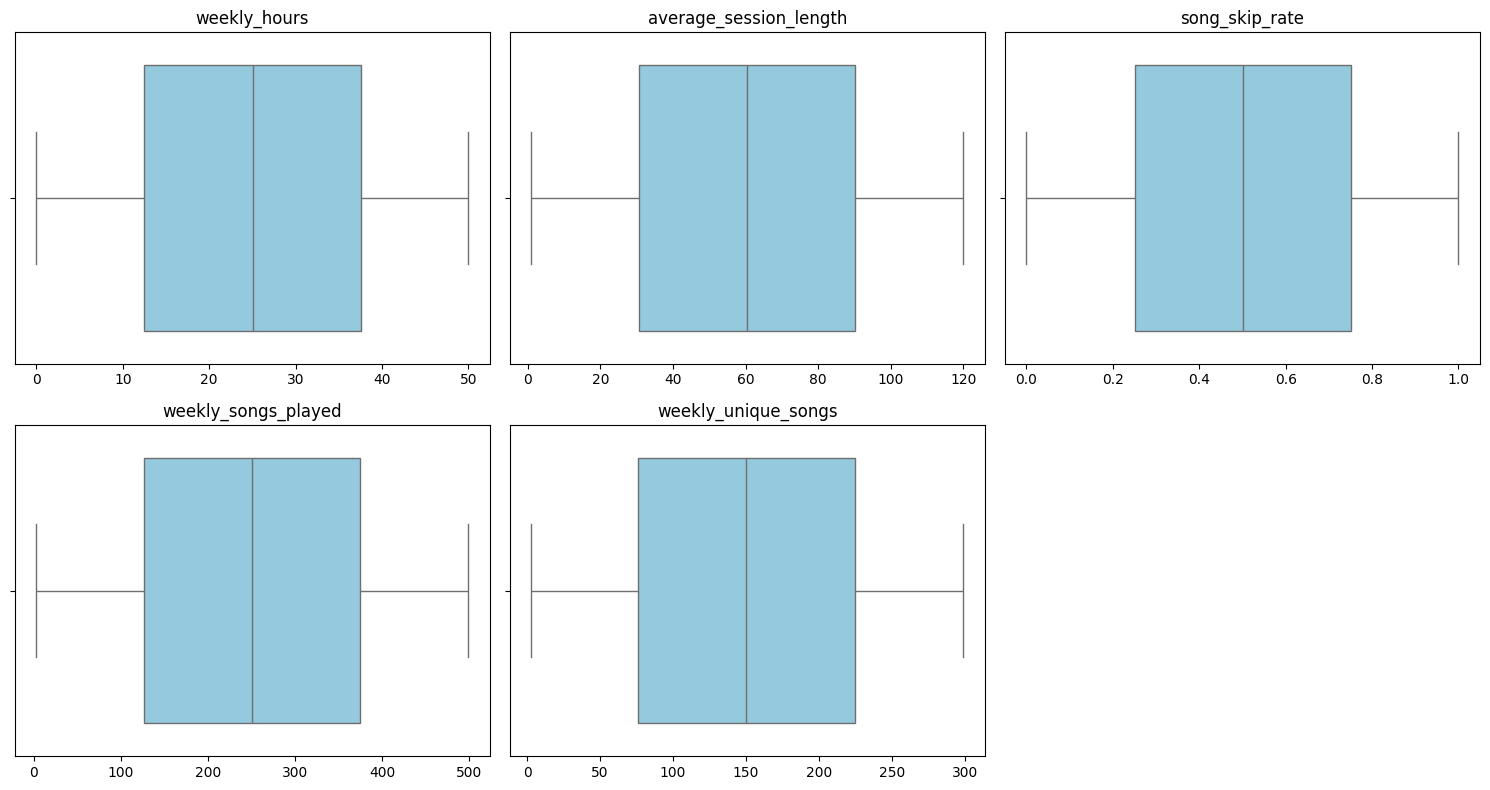

In [ ]:
numeric_usage_cols = [
    "weekly_hours",
    "average_session_length",
    "song_skip_rate",
    "weekly_songs_played",
    "weekly_unique_songs",
]

boxplots_numeric(train_clean, numeric_usage_cols, n_cols=3)


Ahora queremos ver por categoría de churn

In [ ]:
def boxplots_numeric_by_churn(
    df,
    numeric_cols,
    target_col: str = "churned",
    n_cols: int = 3,
    figsize: tuple = (15, 4)
) -> None:
    """
    Dibuja boxplots de variables numéricas separadas por la variable objetivo (churn).

    Parámetros:
    - df: DataFrame.
    - numeric_cols: lista de columnas numéricas.
    - target_col: nombre de la columna de churn (0/1).
    - n_cols: nº de columnas de subplots.
    - figsize: tamaño base de cada fila de subplots.
    """
    n_vars = len(numeric_cols)
    n_rows = (n_vars + n_cols - 1) // n_cols

    plt.figure(figsize=(figsize[0], figsize[1] * n_rows))

    for i, col in enumerate(numeric_cols, 1):
        if col not in df.columns:
            continue

        plt.subplot(n_rows, n_cols, i)
        sns.boxplot(
            data=df,
            x=target_col,
            y=col,
            palette="Set2"
        )
        plt.title(f"{col} vs {target_col}")
        plt.xlabel(target_col)
        plt.ylabel("")

    plt.tight_layout()
    plt.show()


/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/1665766900.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/1665766900.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/1665766900.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/1665766900.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

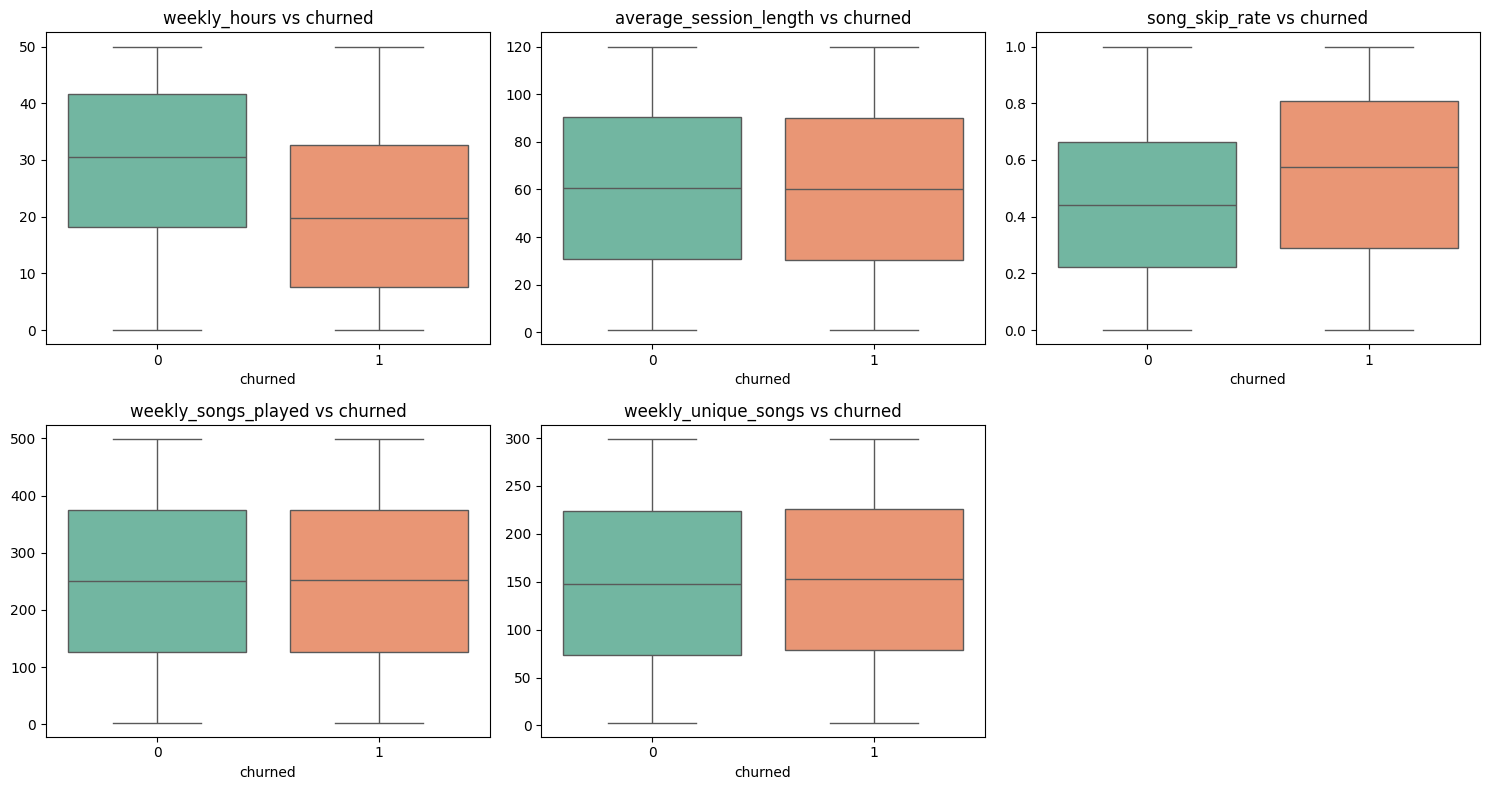

In [ ]:
boxplots_numeric_by_churn(train_clean, numeric_usage_cols, target_col="churned")

## Detectar outliers de forma analítica
Usaremos el método de IQR para detectar outliers.

In [ ]:
def detect_outliers_iqr(df: pd.DataFrame, numeric_cols: list[str], iqr_factor: float = 1.5) -> pd.DataFrame:
    """
    Detecta outliers por columna usando la regla del IQR.

    Parámetros:
    - df: DataFrame de entrada.
    - numeric_cols: lista de columnas numéricas a analizar.
    - iqr_factor: factor multiplicativo del IQR (1.5 es estándar).

    Devuelve:
    - summary_df: DataFrame con estadísticas por columna:
        'column', 'q1', 'q3', 'iqr', 'lower_bound', 'upper_bound',
        'n_outliers', 'pct_outliers'
    """
    records = []

    for col in numeric_cols:
        if col not in df.columns:
            continue

        series = df[col].dropna()
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - iqr_factor * iqr
        upper = q3 + iqr_factor * iqr

        n_outliers = ((series < lower) | (series > upper)).sum()
        pct_outliers = n_outliers / len(series) * 100

        records.append({
            "column": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "n_outliers": n_outliers,
            "pct_outliers": round(pct_outliers, 2),
        })

    summary_df = pd.DataFrame(records).sort_values("pct_outliers", ascending=False)
    print("=== Outliers detectados (regla IQR) ===")
    display(summary_df)
    return summary_df


In [ ]:
numeric_usage_cols = [
    "weekly_hours",
    "average_session_length",
    "song_skip_rate",
    "weekly_songs_played",
    "weekly_unique_songs",
]

outlier_summary = detect_outliers_iqr(train_clean, numeric_usage_cols, iqr_factor=1.5)


=== Outliers detectados (regla IQR) ===


,column,q1,q3,iqr,lower_bound,upper_bound,n_outliers,pct_outliers
0,weekly_hours,12.472667,37.570328,25.097661,-25.173825,75.216819,0,0.0
1,average_session_length,30.644177,90.234158,59.589982,-58.740796,179.619131,0,0.0
2,song_skip_rate,0.250974,0.751110,0.500135,-0.499229,1.501312,0,0.0
3,weekly_songs_played,127.000000,375.000000,248.000000,-245.000000,747.000000,0,0.0
4,weekly_unique_songs,76.000000,225.000000,149.000000,-147.500000,448.500000,0,0.0


Qué hace:

- Para cada columna calcula Q1, Q3, IQR.

- Define límites inferior y superior y cuenta cuántos valores están fuera.

- Devuelve un resumen con número y porcentaje de outliers.

## Creación de nuevas variables a partir de los datos (feature engineering)

Nos interesa realizar varias variables a partir de los datos disponibles. Esto permite hacer un análisis exploratorio más eficaz.

In [ ]:
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Crea variables derivadas para el dataset de churn.
    Usa operaciones vectorizadas cuando es más eficiente
    y lambdas solo donde tiene sentido (reglas simples por valor).
    """
    df = df.copy()

    # 1. Intensidad de uso (vectorizado)
    if {"weekly_songs_played", "weekly_hours"}.issubset(df.columns):
        df["songs_per_hour"] = (
            df["weekly_songs_played"] /
            df["weekly_hours"].clip(lower=1)   # evita divisiones enormes
        )


    # 2. Exploración vs repetición (vectorizado)
    if {"weekly_unique_songs", "weekly_songs_played"}.issubset(df.columns):
        df["unique_ratio"] = (
            df["weekly_unique_songs"] /
            df["weekly_songs_played"].replace(0, np.nan)
        )
        df["unique_ratio"] = df["unique_ratio"].fillna(0).clip(0, 1)

    # 3. Engagement social (vectorizado)
    if {"num_platform_friends", "num_shared_playlists"}.issubset(df.columns):
        df["social_intensity"] = (
            df["num_platform_friends"] + df["num_shared_playlists"]
        )

    if {"num_playlists_created", "num_platform_friends"}.issubset(df.columns):
        df["playlists_per_friend"] = (
            df["num_playlists_created"] / (df["num_platform_friends"] + 1)
        )

    # 4. Flags binarios con lambda cuando hay lógica if/else
    if "num_subscription_pauses" in df.columns:
        df["has_paused"] = df["num_subscription_pauses"].apply(
            lambda x: 1 if x > 0 else 0
        )

    if "song_skip_rate" in df.columns:
        threshold_skip = df["song_skip_rate"].quantile(0.75)
        df["high_skip_user"] = df["song_skip_rate"].apply(
            lambda x: 1 if x > threshold_skip else 0
        )

    # 5. Ordinalizar customer_service_inquiries con lambda + dict
    if "customer_service_inquiries" in df.columns:
        mapping = {"Low": 0, "Medium": 1, "High": 2}
        df["customer_service_inquiries_ord"] = (
            df["customer_service_inquiries"].apply(
                lambda x: mapping.get(x, np.nan)
            )
        )

    # 6. Región geográfica con lambda condicional
    if "location" in df.columns:
        northeast = {"Maine", "New Hampshire", "Vermont", "Massachusetts", "Rhode Island",
                     "Connecticut", "New York", "New Jersey", "Pennsylvania"}
        midwest = {"Ohio", "Indiana", "Illinois", "Michigan", "Wisconsin",
                   "Minnesota", "Iowa", "Missouri", "North Dakota", "South Dakota",
                   "Nebraska", "Kansas"}
        south = {"Delaware", "Maryland", "District of Columbia", "Virginia", "West Virginia",
                 "North Carolina", "South Carolina", "Georgia", "Florida",
                 "Kentucky", "Tennessee", "Alabama", "Mississippi",
                 "Arkansas", "Louisiana", "Oklahoma", "Texas"}
        west = {"Montana", "Idaho", "Wyoming", "Colorado", "New Mexico",
                "Arizona", "Utah", "Nevada", "Washington", "Oregon",
                "California", "Alaska", "Hawaii"}

        df["region"] = df["location"].apply(
            lambda state: (
                "Northeast" if state in northeast else
                "Midwest"   if state in midwest else
                "South"     if state in south else
                "West"      if state in west else
                "Other"
            )
        ).astype("category")

    return df




In [ ]:
train_raw = load_data("dataproject/train.csv")
train_clean = clean_streaming_churn_df(train_raw, is_train=True)
train_feat = add_engineered_features(train_clean)
train_feat


,customer_id,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,signup_date,weekly_hours,...,tenure_days,tenure_months,songs_per_hour,unique_ratio,social_intensity,playlists_per_friend,has_paused,high_skip_user,customer_service_inquiries_ord,region
0,1,32,Montana,Free,Yearly,2,Paypal,Medium,-1606,22.391362,...,1605,53.5,7.547554,0.644970,67,1.575758,1,0,1,West
1,2,64,New Jersey,Free,Monthly,3,Paypal,Low,-2897,29.294210,...,2896,96.5,1.877504,1.000000,58,0.352941,1,1,0,Northeast
2,3,51,Washington,Premium,Yearly,2,Credit Card,High,-348,15.400312,...,347,11.6,15.843835,0.479508,157,0.384615,1,0,2,West
3,4,63,California,Family,Yearly,4,Apple Pay,Medium,-2894,22.842084,...,2893,96.4,19.350248,0.570136,137,0.454545,1,0,1,West
4,5,54,Washington,Family,Monthly,3,Paypal,High,-92,23.151163,...,91,3.0,10.496233,0.946502,98,0.597015,1,0,2,West
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124995,124996,32,California,Student,Monthly,4,Debit Card,Low,-1895,29.161399,...,1894,63.1,15.774277,0.047826,240,0.355000,1,1,0,West
124996,124997,56,Maine,Premium,Yearly,2,Debit Card,Low,-2778,44.744198,...,2777,92.6,7.040019,0.050794,208,0.360215,1,0,0,Northeast
124997,124998,45,Maine,Family,Monthly,0,Paypal,Medium,-604,15.200073,...,603,20.1,0.723681,1.000000,80,1.902439,0,0,1,Northeast
124998,124999,69,Maine,Free,Monthly,4,Paypal,High,-2570,35.270053,...,2569,85.6,12.787052,0.239468,76,0.071429,1,0,2,Northeast


# EDA (Análsis Exploratorio)

A partir de las nuevas variables, vamos a seguir aprendiendo algo sobre el churn. Primero usaremos `songs_per_hour`.

## Boxplot de `songs_per_hour` vs `churned`

In [ ]:
def boxplot_songs_per_hour_by_churn(df, target_col: str = "churned") -> None:
    """
    Boxplot de songs_per_hour separado por churn (0/1).
    """
    if "songs_per_hour" not in df.columns:
        raise ValueError("La columna 'songs_per_hour' no existe. Asegúrate de haber llamado a add_engineered_features.")
    
    plt.figure(figsize=(6, 4))
    sns.boxplot(
        data=df,
        x=target_col,
        y="songs_per_hour",
        palette="Set2"
    )
    plt.title("songs_per_hour vs churn")
    plt.xlabel(target_col)
    plt.ylabel("songs_per_hour")
    plt.tight_layout()
    plt.show()


/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/3979048385.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


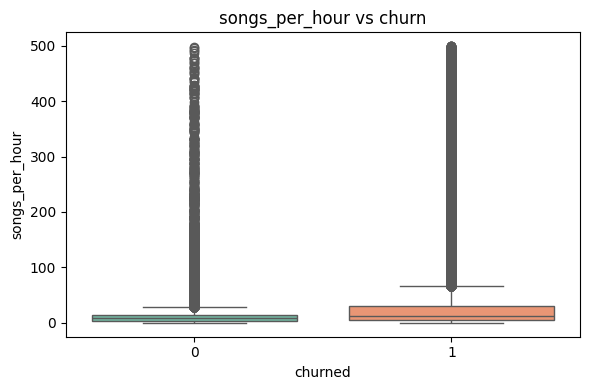

In [ ]:
train_raw = load_data("dataproject/train.csv")
train_clean = clean_streaming_churn_df(train_raw, is_train=True)
train_feat = add_engineered_features(train_clean)

boxplot_songs_per_hour_by_churn(train_feat, target_col="churned")

In [ ]:
train_feat.groupby("churned")["songs_per_hour"].agg(["mean", "median"])
train_feat.groupby("churned")["songs_per_hour"].agg(["mean", "median"])


,mean,median
churned,,
0,13.659271,8.471641
1,35.107077,12.305450


En el boxplot se ve que, en general, el grupo churned = 1 tiene la mediana de songs_per_hour más alta y una caja desplazada hacia valores superiores respecto al grupo 0.

Eso sugiere que, en este dataset, hay bastantes usuarios que abandonan pese a escuchar muchas canciones por hora.

Eso es interesante porque rompe la intuición de “menos uso ⇒ más churn”; aquí parece que la intensidad de uso no protege del abandono, o incluso puede estar asociada a cierto tipo de usuario que churnea más.



## Boxplot de `song_skip_rate` vs `churn`

/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/2968253767.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


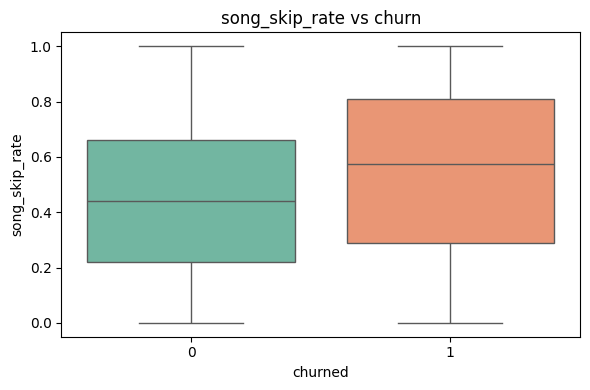

In [ ]:
def boxplot_skip_rate_by_churn(df, target_col: str = "churned") -> None:
    plt.figure(figsize=(6, 4))
    sns.boxplot(
        data=df,
        x=target_col,
        y="song_skip_rate",
        palette="Set2"
    )
    plt.title("song_skip_rate vs churn")
    plt.xlabel(target_col)
    plt.ylabel("song_skip_rate")
    plt.tight_layout()
    plt.show()

boxplot_skip_rate_by_churn(train_feat, target_col="churned")


In [ ]:
train_feat.groupby("churned")["song_skip_rate"].agg(["mean", "median", "std"])


,mean,median,std
churned,,,
0,0.453300,0.440423,0.273691
1,0.545826,0.574558,0.295280


Es decir, los que abandonan saltan más canciones de media y además la distribución está desplazada hacia valores más altos, lo que encaja bastante bien con la idea de “fricción/insatisfacción con el contenido”

## `high_skip_user`vs churn

In [ ]:
train_feat.groupby("high_skip_user")["churned"].mean()

high_skip_user
0    0.462485
1    0.666112
Name: churned, dtype: float64

/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/3321198125.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tmp, x="high_skip_user", y="churned", palette="viridis")


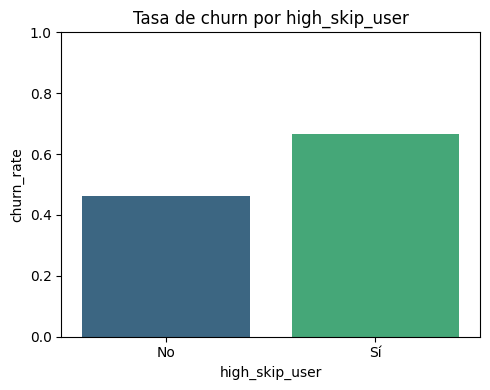

In [ ]:
def barplot_churn_by_high_skip(df) -> None:
    tmp = df.groupby("high_skip_user")["churned"].mean().reset_index()
    tmp["high_skip_user"] = tmp["high_skip_user"].map({0: "No", 1: "Sí"})

    plt.figure(figsize=(5, 4))
    sns.barplot(data=tmp, x="high_skip_user", y="churned", palette="viridis")
    plt.title("Tasa de churn por high_skip_user")
    plt.ylabel("churn_rate")
    plt.xlabel("high_skip_user")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

barplot_churn_by_high_skip(train_feat)


Es decir, en este dataset los usuarios con alto song_skip_rate tienen unas probabilidades de churn mucho más altas que los demás, lo que convierte a song_skip_rate y a tu flag high_skip_user en features muy interesantes para los modelos y para explicaciones de negocio (“usuarios que se saltan más canciones tienen más riesgo de abandonar”).

## Histograma genérico

In [ ]:
def distplot_by_churn(
    df,
    col: str,
    target_col: str = "churned",
    bins: int = 40
) -> None:
    """
    Dibuja histograma + KDE de una variable numérica,
    coloreado por la variable churn (0/1).
    """
    if col not in df.columns:
        raise ValueError(f"La columna {col} no está en el DataFrame.")

    plt.figure(figsize=(7, 4))
    sns.histplot(
        data=df,
        x=col,
        hue=target_col,
        bins=bins,
        stat="density",
        common_norm=False,
        kde=True,
        alpha=0.4
    )
    plt.title(f"Distribución de {col} por {target_col}")
    plt.xlabel(col)
    plt.ylabel("densidad")
    plt.tight_layout()
    plt.show()


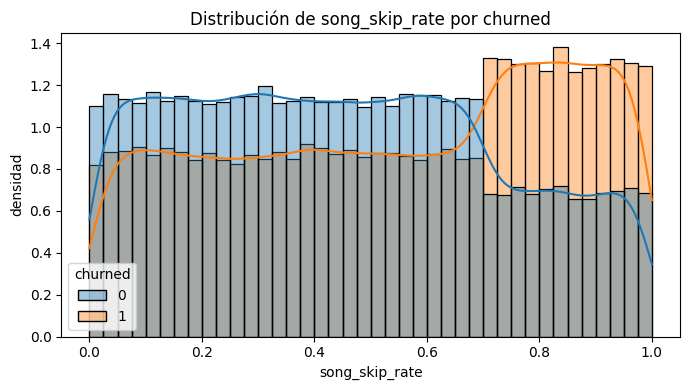

In [ ]:
# song_skip_rate
distplot_by_churn(train_feat, "song_skip_rate", target_col="churned")


- La curva naranja (churned=1) está claramente concentrada en valores altos de song_skip_rate (≈0.7–1).
​

- La curva azul (churned=0) se mueve más por la parte baja y media (≈0–0.6) y cae en la zona de muchos skips.
​

Interpretación: en este dataset, cuanto más alto es el porcentaje de canciones que el usuario se salta, más probable es que haga churn. Esto encaja muy bien con la idea de que el skip es señal de fricción/insatisfacción con lo que escucha.

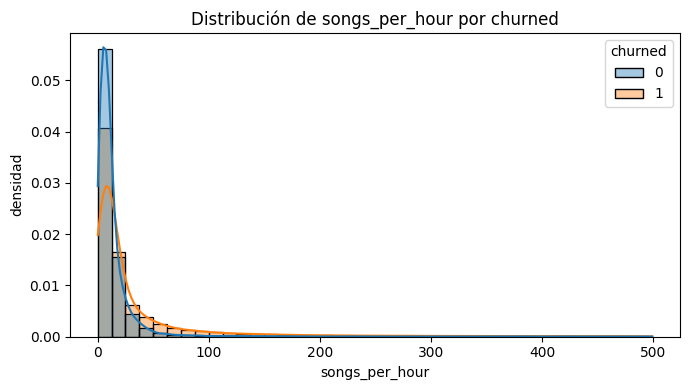

In [ ]:
# songs_per_hour
distplot_by_churn(train_feat, "songs_per_hour", target_col="churned")


- Ambas curvas (azul y naranja) están muy concentradas en valores bajos (pocas decenas de canciones/hora) y caen rápido; la naranja de churned parece algo más extendida hacia la derecha, pero la diferencia es menos dramática que en song_skip_rate.
​

- Eso confirma lo que ya vimos: los churners, de media, escuchan más canciones por hora, pero la separación entre distribuciones no es tan clara.
​

Interpretación: la intensidad de uso (songs_per_hour) tiene cierta señal, pero mucho más débil y ruidosa que song_skip_rate. Probablemente será una feature útil, pero no tan potente ni tan “explicable”.

## Barplots por categorías (subscription type y payment_plan)

In [ ]:
def barplot_churn_by_category(df, col: str, target_col: str = "churned") -> None:
    tmp = (
        df.groupby(col)[target_col]
          .mean()
          .reset_index()
          .rename(columns={target_col: "churn_rate"})
          .sort_values("churn_rate", ascending=False)
    )

    plt.figure(figsize=(6, 4))
    sns.barplot(data=tmp, x=col, y="churn_rate", palette="viridis")
    plt.title(f"Tasa de churn por {col}")
    plt.ylabel("churn_rate")
    plt.xlabel(col)
    plt.ylim(0, 1)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/2375103172.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col)[target_col]
/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/2375103172.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tmp, x=col, y="churn_rate", palette="viridis")


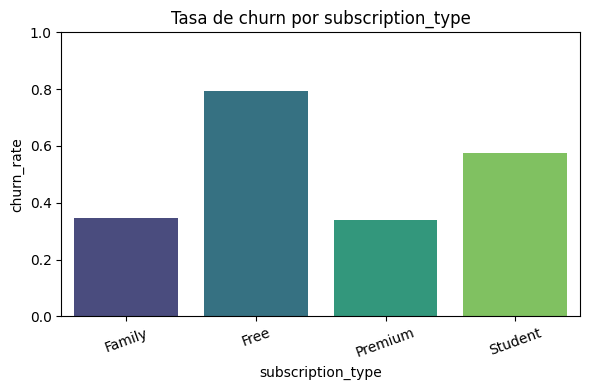

/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/2375103172.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col)[target_col]
/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/2375103172.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tmp, x=col, y="churn_rate", palette="viridis")


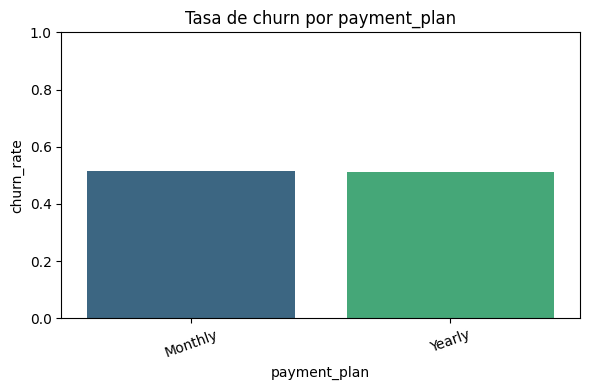

In [ ]:
barplot_churn_by_category(train_feat, "subscription_type")
barplot_churn_by_category(train_feat, "payment_plan")


In [ ]:
def churn_table_by_category(df, col: str, target_col: str = "churned"):
    tmp = (
        df.groupby(col)[target_col]
          .agg(["count", "mean"])
          .rename(columns={"count": "n_obs", "mean": "churn_rate"})
          .reset_index()
          .sort_values("churn_rate", ascending=False)
    )
    print(f"=== {col}: tasa de churn ===")
    display(tmp)
    return tmp

sub_table = churn_table_by_category(train_feat, "subscription_type")
plan_table = churn_table_by_category(train_feat, "payment_plan")


/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/2723446915.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col)[target_col]


=== subscription_type: tasa de churn ===


,subscription_type,n_obs,churn_rate
1,Free,31269,0.794077
3,Student,31305,0.573934
0,Family,31072,0.345810
2,Premium,31354,0.339095


=== payment_plan: tasa de churn ===


/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/2723446915.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col)[target_col]


,payment_plan,n_obs,churn_rate
0,Monthly,62562,0.514066
1,Yearly,62438,0.512717


- Los usuarios Free son, con mucha diferencia, los que más churnean (casi 80%).

- Los de pago Premium y Family tienen tasas de churn bastante más bajas (≈34–35%).

- Student queda en un punto intermedio (≈57%), peor que Premium/Family, mejor que Free.

Esto encaja bien con la intuición de que los usuarios que no pagan o pagan menos tienden a ser menos fieles, y que los planes familiares/premium retienen mejor

El tipo de suscripción (Free, Student, Premium, Family) muestra diferencias claras en churn, mientras que el plan de pago (mensual vs anual) apenas afecta a la probabilidad de abandono

## Exploración de churn vs antiguëdad usando `tenure_months`

Creamos primero los intervalos (buckets) de antiguëdad

In [ ]:
def add_tenure_bucket(df, col: str = "tenure_months") -> pd.DataFrame:
    """
    Crea una columna categórica 'tenure_bucket' a partir de tenure_months.
    """
    df = df.copy()
    if col not in df.columns:
        raise ValueError(f"{col} no está en el DataFrame.")

    bins = [0, 3, 12, 24, 60]  # 0-3, 3-12, 12-24, 24-60 meses
    labels = ["0-3", "3-12", "12-24", "24-60"]
    df["tenure_bucket"] = pd.cut(df[col], bins=bins, labels=labels, right=True, include_lowest=True)
    return df


In [ ]:
train_raw = load_data("dataproject/train.csv")
train_clean = clean_streaming_churn_df(train_raw, is_train=True)
train_feat = add_engineered_features(train_clean)
train_feat_tb = add_tenure_bucket(train_feat)

In [ ]:
def churn_by_tenure_bucket(df, target_col: str = "churned") -> pd.DataFrame:
    """
    Calcula n_obs y churn_rate por tenure_bucket.
    """
    if "tenure_bucket" not in df.columns:
        raise ValueError("Falta 'tenure_bucket'. Llama antes a add_tenure_bucket().")

    tmp = (
        df.groupby("tenure_bucket")[target_col]
          .agg(["count", "mean"])
          .rename(columns={"count": "n_obs", "mean": "churn_rate"})
          .reset_index()
          .sort_values("tenure_bucket")
    )
    print("=== churn por tenure_bucket ===")
    display(tmp)
    return tmp


In [ ]:
tenure_table = churn_by_tenure_bucket(train_feat_tb)

=== churn por tenure_bucket ===


/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/2274123347.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("tenure_bucket")[target_col]


,tenure_bucket,n_obs,churn_rate
0,0-3,4041,0.514972
1,3-12,11513,0.512725
2,12-24,15449,0.509289
3,24-60,46096,0.514925


In [ ]:
def barplot_churn_by_tenure_bucket(df, target_col: str = "churned") -> None:
    if "tenure_bucket" not in df.columns:
        raise ValueError("Falta 'tenure_bucket'. Llama antes a add_tenure_bucket().")

    tmp = (
        df.groupby("tenure_bucket")[target_col]
          .mean()
          .reset_index()
          .rename(columns={target_col: "churn_rate"})
          .sort_values("tenure_bucket")
    )

    plt.figure(figsize=(6, 4))
    sns.barplot(data=tmp, x="tenure_bucket", y="churn_rate", palette="cividis")
    plt.title("Tasa de churn por antigüedad (meses)")
    plt.ylabel("churn_rate")
    plt.xlabel("tenure_bucket (meses)")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/2613462383.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("tenure_bucket")[target_col]
/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/2613462383.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tmp, x="tenure_bucket", y="churn_rate", palette="cividis")


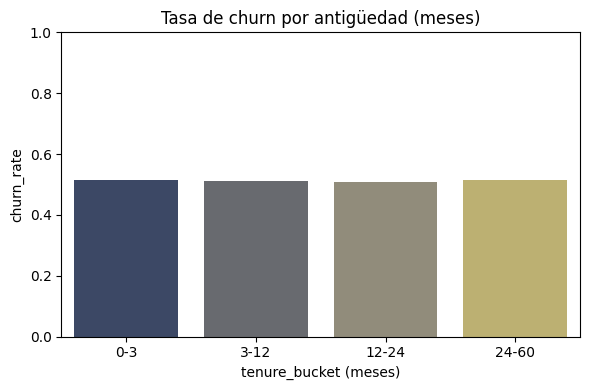

In [ ]:
barplot_churn_by_tenure_bucket(train_feat_tb)

En este dataset, la antigüedad (0–60 meses) no parece influir apenas en el churn. No se ve el patrón típico de “churn alto al principio y más bajo después”, ni lo contrario.
​

Por tanto, tenure_months probablemente será una feature con muy poco peso en el modelo comparada con cosas como song_skip_rate, high_skip_user o subscription_type, donde sí veíamos diferencias grandes.

## Variables geográficas con mapas

### Churn por estado (`location`)

Primero sacamos churn por estado para usarlo en barplots o mapas

In [ ]:
def churn_by_state(df, target_col: str = "churned") -> pd.DataFrame:
    """
    Calcula tasa de churn y nº de usuarios por estado (location).
    """
    if "location" not in df.columns:
        raise ValueError("Falta la columna 'location'.")

    tmp = (
        df.groupby("location")[target_col]
          .agg(["count", "mean"])
          .rename(columns={"count": "n_users", "mean": "churn_rate"})
          .reset_index()
    )

    # ordenar de mayor a menor churn
    tmp = tmp.sort_values("churn_rate", ascending=False)
    print("=== churn por estado (location) ===")
    display(tmp.head(10))   # top 10 con mayor churn
    return tmp


In [ ]:
state_churn = churn_by_state(train_feat)


=== churn por estado (location) ===


/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/1063124861.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("location")[target_col]


,location,n_users,churn_rate
3,Georgia,6705,0.521551
16,Washington,6638,0.517324
18,Wisconsin,6553,0.517168
8,New Jersey,6634,0.516883
12,South Carolina,6534,0.516529
11,North Dakota,6577,0.516041
14,Vermont,6676,0.515578
13,Utah,6577,0.514824
1,California,6665,0.513878
17,West Virginia,6486,0.513876


No parece haber un patrón geográfico fuerte a nivel de estado en este dataset: a diferencia de subscription_type o song_skip_rate, donde las diferencias eran grandes, aquí todos los estados están alrededor del mismo churn.

### Churn por región

In [ ]:
def churn_by_region(df, target_col: str = "churned") -> pd.DataFrame:
    """
    Calcula nº de usuarios y tasa de churn por región.
    Supone que ya existe la columna 'region' en el DataFrame.
    """
    if "region" not in df.columns:
        raise ValueError("Falta la columna 'region'. Asegúrate de llamar a add_engineered_features antes.")

    tmp = (
        df.groupby("region")[target_col]
          .agg(["count", "mean"])
          .rename(columns={"count": "n_users", "mean": "churn_rate"})
          .reset_index()
          .sort_values("churn_rate", ascending=False)
    )

    print("=== churn por región ===")
    display(tmp)
    return tmp


In [ ]:
region_table = churn_by_region(train_feat)


=== churn por región ===


/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/255711123.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("region")[target_col]


,region,n_users,churn_rate
0,Midwest,13130,0.516603
4,West,32978,0.513949
2,Other,6601,0.512953
3,South,45884,0.512859
1,Northeast,26407,0.512137


#### Barplot de churn por región

In [ ]:
def barplot_churn_by_region(df, target_col: str = "churned") -> None:
    """
    Barplot de tasa de churn por región.
    """
    if "region" not in df.columns:
        raise ValueError("Falta la columna 'region'.")

    tmp = (
        df.groupby("region")[target_col]
          .mean()
          .reset_index()
          .rename(columns={target_col: "churn_rate"})
          .sort_values("churn_rate", ascending=False)
    )

    plt.figure(figsize=(6, 4))
    sns.barplot(data=tmp, x="region", y="churn_rate", palette="magma")
    plt.title("Tasa de churn por región")
    plt.ylabel("churn_rate")
    plt.xlabel("region")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/851717818.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("region")[target_col]
/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/851717818.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tmp, x="region", y="churn_rate", palette="magma")


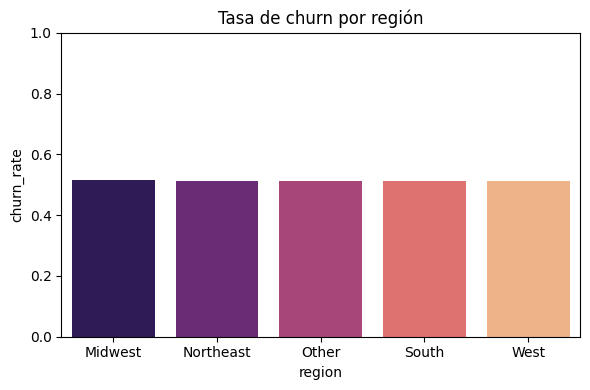

In [ ]:
barplot_churn_by_region(train_feat)


### Usuarios por región

In [ ]:
def users_by_region(df) -> pd.DataFrame:
    """
    Cuenta usuarios por región y calcula también churn_rate
    (para tener ambas cosas juntas).
    """
    if "region" not in df.columns:
        raise ValueError("Falta la columna 'region'.")

    tmp = (
        df.groupby("region")["churned"]
          .agg(["count", "mean"])
          .rename(columns={"count": "n_users", "mean": "churn_rate"})
          .reset_index()
          .sort_values("n_users", ascending=False)
    )
    print("=== usuarios y churn por región ===")
    display(tmp)
    return tmp


In [ ]:
def barplot_users_by_region(region_df: pd.DataFrame) -> None:
    plt.figure(figsize=(6, 4))
    sns.barplot(data=region_df, x="region", y="n_users", palette="Blues")
    plt.title("Número de usuarios por región")
    plt.ylabel("n_users")
    plt.xlabel("region")
    plt.tight_layout()
    plt.show()


=== usuarios y churn por región ===


/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/3885877757.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("region")["churned"]


,region,n_users,churn_rate
3,South,45884,0.512859
4,West,32978,0.513949
1,Northeast,26407,0.512137
0,Midwest,13130,0.516603
2,Other,6601,0.512953


/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/107540940.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_df, x="region", y="n_users", palette="Blues")


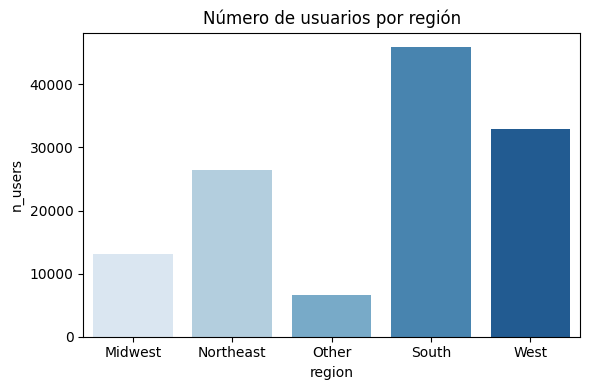

In [ ]:
region_stats = users_by_region(train_feat)
barplot_users_by_region(region_stats)


## Barplot de churn por `customer_service_inquiries`

In [ ]:
def churn_table_by_category(df, col: str, target_col: str = "churned"):
    tmp = (
        df.groupby(col)[target_col]
          .agg(["count", "mean"])
          .rename(columns={"count": "n_obs", "mean": "churn_rate"})
          .reset_index()
          .sort_values("churn_rate", ascending=False)
    )
    display(tmp)
    return tmp

def barplot_churn_by_category(df, col: str, target_col: str = "churned") -> None:
    tmp = (
        df.groupby(col)[target_col]
          .mean()
          .reset_index()
          .rename(columns={target_col: "churn_rate"})
          .sort_values("churn_rate", ascending=False)
    )

    plt.figure(figsize=(6, 4))
    sns.barplot(data=tmp, x=col, y="churn_rate", palette="viridis")
    plt.title(f"Tasa de churn por {col}")
    plt.ylabel("churn_rate")
    plt.xlabel(col)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/992368621.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col)[target_col]


,customer_service_inquiries,n_obs,churn_rate
0,High,41583,0.743333
2,Medium,41544,0.509171
1,Low,41873,0.289232


/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/992368621.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col)[target_col]
/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/992368621.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tmp, x=col, y="churn_rate", palette="viridis")


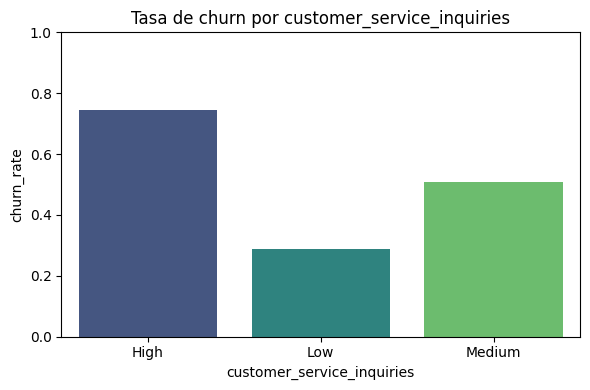

In [ ]:
cs_table = churn_table_by_category(train_feat, "customer_service_inquiries")
barplot_churn_by_category(train_feat, "customer_service_inquiries")


## Bins de weekly_hours y churn

In [ ]:
def add_weekly_hours_bin(df, col: str = "weekly_hours") -> pd.DataFrame:
    df = df.copy()
    bins = [0, 5, 10, 40, 50, np.inf]
    labels = ["0-5", "5-10", "10-40", "40-50", ">50"]
    df["weekly_hours_bin"] = pd.cut(df[col], bins=bins, labels=labels, include_lowest=True)
    return df

def churn_by_weekly_hours_bin(df, target_col: str = "churned") -> pd.DataFrame:
    if "weekly_hours_bin" not in df.columns:
        raise ValueError("Falta 'weekly_hours_bin'")
    tmp = (
        df.groupby("weekly_hours_bin")[target_col]
          .agg(["count", "mean"])
          .rename(columns={"count": "n_obs", "mean": "churn_rate"})
          .reset_index()
          .sort_values("weekly_hours_bin")
    )
    display(tmp)
    return tmp

def barplot_churn_by_weekly_hours_bin(df, target_col: str = "churned") -> None:
    tmp = (
        df.groupby("weekly_hours_bin")[target_col]
          .mean()
          .reset_index()
          .rename(columns={target_col: "churn_rate"})
          .sort_values("weekly_hours_bin")
    )

    plt.figure(figsize=(6, 4))
    sns.barplot(data=tmp, x="weekly_hours_bin", y="churn_rate", palette="cividis")
    plt.title("Tasa de churn por weekly_hours (bins)")
    plt.ylabel("churn_rate")
    plt.xlabel("weekly_hours_bin")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/2966404808.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("weekly_hours_bin")[target_col]


,weekly_hours_bin,n_obs,churn_rate
0,0-5,12447,0.891219
1,5-10,12536,0.725431
2,10-40,75007,0.495567
3,40-50,25010,0.272531
4,>50,0,NaN


/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/2966404808.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("weekly_hours_bin")[target_col]
/var/folders/c5/zwyc201564b7l_drzhj5njy00000gn/T/ipykernel_62441/2966404808.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tmp, x="weekly_hours_bin", y="churn_rate", palette="cividis")


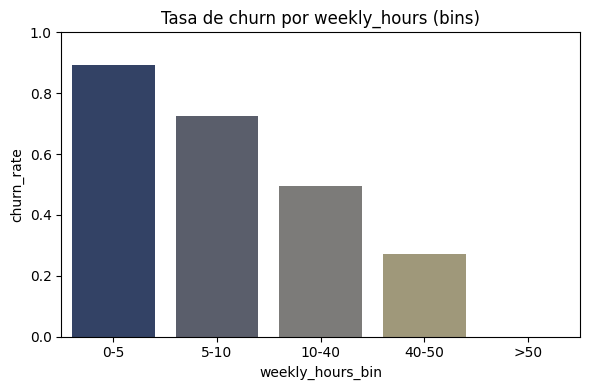

In [ ]:
train_feat_wh = add_weekly_hours_bin(train_feat)
wh_table = churn_by_weekly_hours_bin(train_feat_wh)
barplot_churn_by_weekly_hours_bin(train_feat_wh)


# EDA interactivo

In [ ]:
df = pd.read_csv("dataproject/train.csv")
df.head()

,customer_id,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,signup_date,weekly_hours,average_session_length,song_skip_rate,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned
0,1,32,Montana,Free,Yearly,2,Paypal,Medium,-1606,22.391362,105.394516,0.176873,169,109,18,32,52,35,46,0
1,2,64,New Jersey,Free,Monthly,3,Paypal,Low,-2897,29.294210,52.501115,0.981811,55,163,44,33,12,25,37,1
2,3,51,Washington,Premium,Yearly,2,Credit Card,High,-348,15.400312,24.703696,0.048411,244,117,20,129,50,28,38,0
3,4,63,California,Family,Yearly,4,Apple Pay,Medium,-2894,22.842084,83.595480,0.035691,442,252,47,120,55,17,24,0
4,5,54,Washington,Family,Monthly,3,Paypal,High,-92,23.151163,52.578266,0.039738,243,230,41,66,40,32,47,0


In [ ]:
def churn_rate(df, target="churned"):
    """
    Devuelve la tasa global de churn en porcentaje.
    """
    return df[target].mean() * 100


def add_tenure_from_signup(df, signup_col="signup_date"):
    """
    Crea una columna 'tenure_days' a partir de signup_date.
    En este dataset signup_date aparece en negativo, así que invertimos el signo.
    Devuelve una copia del dataframe.
    """
    df_copy = df.copy()
    df_copy["tenure_days"] = -df_copy[signup_col]
    return df_copy


def create_binned_column(df, column, bins, labels=None, new_col_name=None):
    """
    Crea una columna categórica a partir de una variable numérica usando bins.
    Devuelve una copia del dataframe.
    """
    df_copy = df.copy()
    
    if new_col_name is None:
        new_col_name = f"{column}_bin"
    
    df_copy[new_col_name] = pd.cut(df_copy[column], bins=bins, labels=labels, include_lowest=True)
    return df_copy

In [ ]:
def plot_global_churn(df, target="churned"):
    """
    Muestra un gráfico interactivo con la distribución global de churn.
    """
    churn_pct = df[target].mean() * 100
    no_churn_pct = 100 - churn_pct
    
    plot_df = pd.DataFrame({
        "Estado": ["No churn", "Churn"],
        "Porcentaje": [no_churn_pct, churn_pct]
    })
    
    fig = px.bar(
        plot_df,
        x="Estado",
        y="Porcentaje",
        text="Porcentaje",
        title="Distribución global del churn"
    )
    
    fig.update_traces(texttemplate="%{text:.2f}%", textposition="outside")
    fig.update_layout(yaxis_title="Porcentaje", xaxis_title="")
    
    fig.show(renderer="browser")

In [ ]:
def plot_churn_by_category(df, category_col, target="churned", sort_desc=True):
    """
    Grafica la tasa de churn (%) por una variable categórica.
    """
    plot_df = (
        df.groupby(category_col)[target]
        .mean()
        .reset_index()
        .assign(churn_pct=lambda x: x[target] * 100)
        [[category_col, "churn_pct"]]
    )
    
    if sort_desc:
        plot_df = plot_df.sort_values("churn_pct", ascending=False)
    
    fig = px.bar(
        plot_df,
        x=category_col,
        y="churn_pct",
        text="churn_pct",
        title=f"Tasa de churn por {category_col}"
    )
    
    fig.update_traces(texttemplate="%{text:.2f}%", textposition="outside")
    fig.update_layout(yaxis_title="Churn (%)", xaxis_title=category_col)
    
    fig.show(renderer="browser")

In [ ]:
def plot_churn_by_numeric_bins(df, numeric_col, bins, labels=None, target="churned", new_col_name=None):
    """
    Divide una variable numérica en intervalos y grafica la tasa de churn por intervalo.
    """
    df_binned = create_binned_column(df, numeric_col, bins=bins, labels=labels, new_col_name=new_col_name)
    
    if new_col_name is None:
        new_col_name = f"{numeric_col}_bin"
    
    plot_df = (
        df_binned.groupby(new_col_name, observed=False)[target]
        .mean()
        .reset_index()
        .assign(churn_pct=lambda x: x[target] * 100)
        [[new_col_name, "churn_pct"]]
    )
    
    fig = px.bar(
        plot_df,
        x=new_col_name,
        y="churn_pct",
        text="churn_pct",
        title=f"Tasa de churn por intervalos de {numeric_col}"
    )
    
    fig.update_traces(texttemplate="%{text:.2f}%", textposition="outside")
    fig.update_layout(yaxis_title="Churn (%)", xaxis_title=numeric_col)
    
    fig.show(renderer="browser")

In [ ]:
def plot_box_by_churn(df, numeric_col, target="churned"):
    """
    Muestra un boxplot interactivo de una variable numérica según churn/no churn.
    """
    df_copy = df.copy()
    df_copy["churn_label"] = df_copy[target].map({0: "No churn", 1: "Churn"})
    
    fig = px.box(
        df_copy,
        x="churn_label",
        y=numeric_col,
        color="churn_label",
        title=f"Distribución de {numeric_col} según churn"
    )
    
    fig.update_layout(xaxis_title="", yaxis_title=numeric_col, showlegend=False)
    fig.show(renderer="browser")

In [ ]:
def plot_churn_heatmap(df, row_col, col_col, target="churned"):
    """
    Heatmap de tasa de churn (%) para la combinación de dos variables categóricas.
    """
    heatmap_df = (
        df.groupby([row_col, col_col])[target]
        .mean()
        .reset_index()
        .assign(churn_pct=lambda x: x[target] * 100)
        .pivot(index=row_col, columns=col_col, values="churn_pct")
    )
    
    fig = px.imshow(
        heatmap_df,
        text_auto=".2f",
        aspect="auto",
        title=f"Heatmap de churn (%) entre {row_col} y {col_col}",
        labels=dict(color="Churn (%)")
    )
    
    fig.show(renderer="browser")

In [ ]:
def plot_histogram_by_churn(df, numeric_col, target="churned", nbins=30):
    """
    Histograma interactivo de una variable numérica separado por churn.
    """
    df_copy = df.copy()
    df_copy["churn_label"] = df_copy[target].map({0: "No churn", 1: "Churn"})
    
    fig = px.histogram(
        df_copy,
        x=numeric_col,
        color="churn_label",
        barmode="overlay",
        nbins=nbins,
        opacity=0.65,
        title=f"Distribución de {numeric_col} según churn"
    )
    
    fig.update_layout(xaxis_title=numeric_col, yaxis_title="Frecuencia")
    fig.show(renderer="browser")

In [ ]:
print(f"Tasa global de churn: {churn_rate(df):.2f}%")
plot_global_churn(df)

Tasa global de churn: 51.34%


In [ ]:
plot_churn_by_category(df, "subscription_type")

### Comentario
Este gráfico permite comprobar si el tipo de suscripción está relacionado con el churn.

La hipótesis es que los usuarios del plan **Free** tendrán una tasa de abandono superior a los usuarios con planes de pago, ya que su compromiso con la plataforma es menor.

In [ ]:
plot_churn_by_category(df, "customer_service_inquiries")

### Comentario
Aquí se estudia si el nivel de consultas o incidencias con atención al cliente se asocia con mayor churn.

Si la tasa de abandono aumenta en los niveles altos, podría interpretarse como una señal de fricción o mala experiencia de usuario.

In [ ]:
weekly_hours_bins = [0, 5, 10, 20, 30, 40, 50]
weekly_hours_labels = ["0-5", "5-10", "10-20", "20-30", "30-40", "40-50"]

plot_churn_by_numeric_bins(
    df,
    numeric_col="weekly_hours",
    bins=weekly_hours_bins,
    labels=weekly_hours_labels
)

### Comentario
Esta visualización ayuda a estudiar si el engagement semanal protege frente al churn.

La expectativa es que los usuarios con pocas horas de uso semanal presenten una tasa de abandono bastante mayor.

In [ ]:
plot_churn_by_category(df, "num_subscription_pauses", sort_desc=False)

### Comentario
El número de pausas en la suscripción puede actuar como señal de inestabilidad en el uso del servicio.

Si la tasa de churn aumenta con el número de pausas, esta variable podría ser una señal temprana de abandono.

In [ ]:
skip_bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
skip_labels = ["0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]

plot_churn_by_numeric_bins(
    df,
    numeric_col="song_skip_rate",
    bins=skip_bins,
    labels=skip_labels
)

### Comentario
El song skip rate puede reflejar menor satisfacción con el contenido o menor ajuste entre usuario y recomendaciones.

Una tasa alta de canciones saltadas podría estar asociada a un mayor churn.

In [ ]:
age_bins = [18, 25, 35, 50, 65, 80]
age_labels = ["18-24", "25-34", "35-49", "50-64", "65-79"]

plot_churn_by_numeric_bins(
    df,
    numeric_col="age",
    bins=age_bins,
    labels=age_labels
)

### Comentario
La edad puede influir en el comportamiento del usuario, aunque no necesariamente de forma lineal.

Por eso resulta más útil analizarla por tramos que como una variable continua sin más.

In [ ]:
plot_churn_heatmap(df, "subscription_type", "customer_service_inquiries")

### Comentario
Este heatmap permite estudiar el efecto conjunto de dos variables que, por separado, ya parecen muy relevantes.

Es útil para detectar segmentos especialmente vulnerables, por ejemplo usuarios **Free** con muchas incidencias.

In [ ]:
plot_box_by_churn(df, "weekly_hours")
plot_box_by_churn(df, "song_skip_rate")
plot_box_by_churn(df, "average_session_length")

In [ ]:
plot_histogram_by_churn(df, "weekly_hours")
plot_histogram_by_churn(df, "song_skip_rate")

## Conclusiones preliminares del EDA

A partir de los gráficos anteriores, las señales más fuertes de churn parecen concentrarse en tres grandes bloques:

- **Tipo de usuario**: especialmente el tipo de suscripción.
- **Engagement**: medido, por ejemplo, a través de las horas semanales de uso.
- **Fricción o señales de abandono**: como las incidencias con atención al cliente o las pausas en la suscripción.

Estas observaciones serán útiles tanto para la fase de modelado como para la interpretación de resultados desde una perspectiva de negocio.